In [1]:
from google.colab import files

uploaded = files.upload()

Saving cineplanet.csv to cineplanet.csv


In [2]:
import pandas as pd

df = pd.read_csv( 'cineplanet.csv')

df.head()

,ID_Cliente,Edad,Genero,Ingreso_Mensual,Frecuencia_Visitas_Mes,Dia_Visita,Genero_Pelicula,Precio_Entrada,Promocion,Compra_Entrada
0,1,45,F,4767,1,Lunes,Drama,14,No,No
1,2,42,F,4642,1,Viernes,Comedia,22,No,Si
2,3,29,M,2579,2,Sabado,Accion,18,Si,Si
3,4,30,M,2643,2,Viernes,Comedia,18,Si,Si
4,5,33,F,3581,2,Viernes,Romance,21,Si,Si


In [3]:
import numpy as np

n = 1500

nuevo_df = df.sample(
    n=n,
    replace=True
).reset_index(drop=True)

nuevo_df["Edad"] = nuevo_df["Edad"] + np.random.randint(-2,3,n)

nuevo_df["Ingreso_Mensual"] = (
    nuevo_df["Ingreso_Mensual"]
    + np.random.randint(-300,301,n)
)

nuevo_df["Precio_Entrada"] = (
    nuevo_df["Precio_Entrada"]
    + np.random.randint(-2,3,n)
)

nuevo_df["ID_Cliente"] = range(1,n+1)

nuevo_df.head()

,ID_Cliente,Edad,Genero,Ingreso_Mensual,Frecuencia_Visitas_Mes,Dia_Visita,Genero_Pelicula,Precio_Entrada,Promocion,Compra_Entrada
0,1,23,M,2252,3,Sabado,Accion,16,Si,Si
1,2,25,M,1575,4,Domingo,Terror,19,Si,Si
2,3,34,F,3466,1,Martes,Drama,16,No,No
3,4,17,M,1615,4,Sabado,Terror,16,Si,Si
4,5,47,F,5770,1,Martes,Drama,14,No,No


In [4]:
nuevo_df.to_csv(
    'cineplanet.csv',
    index=False
)

In [5]:
df = pd.read_csv('cineplanet.csv')

In [6]:
from sklearn.preprocessing import StandardScaler

X = df[['Edad',
        'Ingreso_Mensual',
        'Frecuencia_Visitas_Mes',
        'Precio_Entrada']]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.97143498 -0.58317063  0.67830973 -0.57563038]
 [-0.75623007 -1.0806754   1.53188741  0.39671824]
 [ 0.21219204  0.30895756 -1.02884563 -0.57563038]
 [-1.61704972 -1.05128073  1.53188741 -0.57563038]
 [ 1.61102398  2.00209048 -1.02884563 -1.2238628 ]]


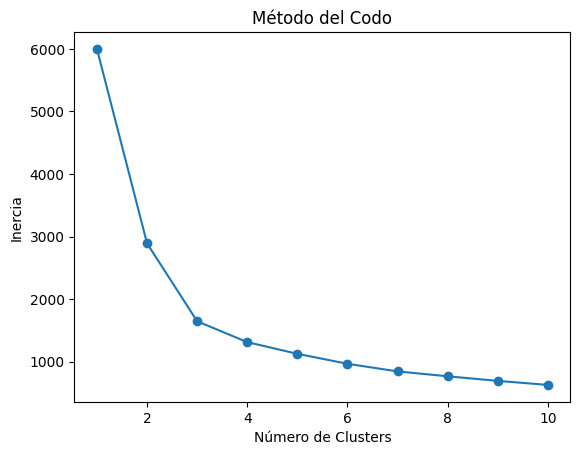

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1,11):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

plt.plot(range(1,11), inercia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,ID_Cliente,Edad,Genero,Ingreso_Mensual,Frecuencia_Visitas_Mes,Dia_Visita,Genero_Pelicula,Precio_Entrada,Promocion,Compra_Entrada,Cluster
0,1,23,M,2252,3,Sabado,Accion,16,Si,Si,3
1,2,25,M,1575,4,Domingo,Terror,19,Si,Si,3
2,3,34,F,3466,1,Martes,Drama,16,No,No,1
3,4,17,M,1615,4,Sabado,Terror,16,Si,Si,3
4,5,47,F,5770,1,Martes,Drama,14,No,No,1


In [10]:
df['Cluster'].value_counts()

,count
Cluster,
0,457
1,422
2,317
3,304


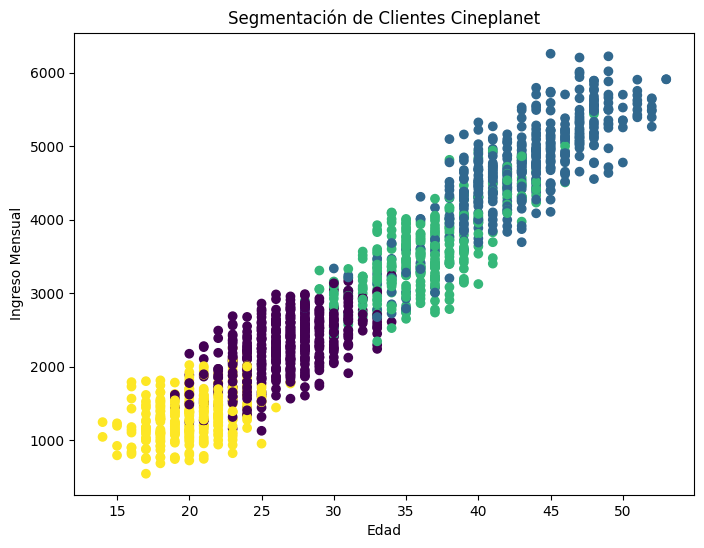

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Edad'],
    df['Ingreso_Mensual'],
    c=df['Cluster']
)

plt.xlabel("Edad")
plt.ylabel("Ingreso Mensual")
plt.title("Segmentación de Clientes Cineplanet")

plt.show()

In [12]:
print(df.shape)

(1500, 11)


In [13]:
df.head()

,ID_Cliente,Edad,Genero,Ingreso_Mensual,Frecuencia_Visitas_Mes,Dia_Visita,Genero_Pelicula,Precio_Entrada,Promocion,Compra_Entrada,Cluster
0,1,23,M,2252,3,Sabado,Accion,16,Si,Si,3
1,2,25,M,1575,4,Domingo,Terror,19,Si,Si,3
2,3,34,F,3466,1,Martes,Drama,16,No,No,1
3,4,17,M,1615,4,Sabado,Terror,16,Si,Si,3
4,5,47,F,5770,1,Martes,Drama,14,No,No,1


In [14]:
import os

os.listdir()

['.config', 'cineplanet.csv', 'sample_data']

In [21]:
df.groupby('Cluster')[['Edad',
                       'Ingreso_Mensual',
                       'Frecuencia_Visitas_Mes',
                       'Precio_Entrada']].mean()

,Edad,Ingreso_Mensual,Frecuencia_Visitas_Mes,Precio_Entrada
Cluster,,,,
0,26.746171,2283.814004,2.336980,19.295405
1,43.026066,4707.248815,1.007109,14.777251
2,36.309148,3550.126183,1.798107,20.675079
3,20.236842,1357.921053,4.095395,16.631579


In [16]:
nuevo_cliente = pd.DataFrame({
    'Edad':[20],
    'Ingreso_Mensual':[1400],
    'Frecuencia_Visitas_Mes':[6],
    'Precio_Entrada':[15]
})

nuevo_scaled = scaler.transform(nuevo_cliente)

cluster = kmeans.predict(nuevo_scaled)

print("El cliente pertenece al Cluster:", cluster[0])

El cliente pertenece al Cluster: 3


In [22]:
# Información de cada segmento

# Información de cada segmento (AJUSTADA A LOS RESULTADOS DEL MODELO)

segmentos = {

    0: {
        "nombre": "Jóvenes Profesionales",
        "descripcion": "Clientes jóvenes adultos con ingresos medios y frecuencia moderada de visitas.",
        "estrategia": "Promociones para grupos, combos de fin de semana y beneficios por compras recurrentes.",
        "canal": "Instagram, Facebook y App",
        "objetivo": "Incrementar el ticket promedio."
    },

    1: {
        "nombre": "Clientes Premium",
        "descripcion": "Clientes con altos ingresos que visitan el cine pocas veces al mes.",
        "estrategia": "Funciones VIP, preventas exclusivas y combos premium personalizados.",
        "canal": "Correo electrónico y aplicación móvil",
        "objetivo": "Incrementar la frecuencia de visitas."
    },

    2: {
        "nombre": "Clientes Ocasionales",
        "descripcion": "Clientes con ingresos medios que visitan el cine de forma esporádica.",
        "estrategia": "Cupones personalizados, promociones 2x1 y recordatorios de estrenos.",
        "canal": "Correo electrónico y SMS",
        "objetivo": "Incrementar la cantidad de visitas."
    },

    3: {
        "nombre": "Jóvenes Cinéfilos",
        "descripcion": "Clientes jóvenes con alta frecuencia de visitas y menor poder adquisitivo.",
        "estrategia": "Descuentos para estudiantes, programa de puntos y promociones 2x1.",
        "canal": "Instagram y TikTok",
        "objetivo": "Aumentar el consumo y fidelizar clientes."
    }

}

In [23]:
# Obtener la información del segmento identificado

info = segmentos[cluster[0]]

print("="*55)
print("           CINESMART IA")
print("="*55)

print(f"\nSegmento identificado: {info['nombre']}")

print(f"\nDescripción:")
print(info['descripcion'])

print(f"\nEstrategia publicitaria recomendada:")
print(info['estrategia'])

print(f"\nCanal de marketing recomendado:")
print(info['canal'])

print(f"\nObjetivo empresarial:")
print(info['objetivo'])

print("\n" + "="*55)

           CINESMART IA

Segmento identificado: Jóvenes Cinéfilos

Descripción:
Clientes jóvenes con alta frecuencia de visitas y menor poder adquisitivo.

Estrategia publicitaria recomendada:
Descuentos para estudiantes, programa de puntos y promociones 2x1.

Canal de marketing recomendado:
Instagram y TikTok

Objetivo empresarial:
Aumentar el consumo y fidelizar clientes.



In [26]:
# ==========================
# DEMO FUNCIONAL CINESMART IA
# ==========================

print("="*55)
print("            CINESMART IA")
print("="*55)

edad = float(input("Ingrese la edad del cliente: "))
ingreso = float(input("Ingrese el ingreso mensual (S/): "))
frecuencia = float(input("Ingrese la frecuencia de visitas al mes: "))
precio = float(input("Ingrese el precio promedio de entrada (S/): "))

import pandas as pd

nuevo_cliente = pd.DataFrame({
    "Edad": [edad],
    "Ingreso_Mensual": [ingreso],
    "Frecuencia_Visitas_Mes": [frecuencia],
    "Precio_Entrada": [precio]
})

nuevo_cliente_scaled = scaler.transform(nuevo_cliente)

# Predecir el cluster
cluster_predicho = kmeans.predict(nuevo_cliente_scaled)[0]

# Obtener información del segmento
info = segmentos[cluster_predicho]

print("\n" + "="*55)
print("RESULTADO DEL ANÁLISIS")
print("="*55)

print(f"\nSegmento identificado: {info['nombre']}")
print(f"\nDescripción:")
print(info['descripcion'])

print(f"\nEstrategia publicitaria recomendada:")
print(info['estrategia'])

print(f"\nCanal recomendado:")
print(info['canal'])

print(f"\nObjetivo empresarial:")
print(info['objetivo'])

print("\nGracias por utilizar CineSmart IA.")
print("="*55)

            CINESMART IA
Ingrese la edad del cliente: 20
Ingrese el ingreso mensual (S/): 1200
Ingrese la frecuencia de visitas al mes: 5
Ingrese el precio promedio de entrada (S/): 18

RESULTADO DEL ANÁLISIS

Segmento identificado: Jóvenes Cinéfilos

Descripción:
Clientes jóvenes con alta frecuencia de visitas y menor poder adquisitivo.

Estrategia publicitaria recomendada:
Descuentos para estudiantes, programa de puntos y promociones 2x1.

Canal recomendado:
Instagram y TikTok

Objetivo empresarial:
Aumentar el consumo y fidelizar clientes.

Gracias por utilizar CineSmart IA.


In [27]:
# ==========================
# MOTOR DE RECOMENDACIONES
# ==========================

campanias = {

    "Clientes Premium": {
        "Promoción": "20% de descuento en funciones VIP.",
        "Combo": "Combo Premium Familiar.",
        "Canal": "Correo electrónico y App.",
        "Objetivo": "Incrementar visitas de clientes de alto valor."
    },

    "Jóvenes Cinéfilos": {
        "Promoción": "2x1 para estudiantes de lunes a jueves.",
        "Combo": "Combo Clásico + Gaseosa.",
        "Canal": "Instagram y TikTok.",
        "Objetivo": "Incrementar la frecuencia de visitas."
    },

    "Clientes Ocasionales": {
        "Promoción": "Cupón de S/10 para la próxima compra.",
        "Combo": "Combo Familiar.",
        "Canal": "Correo electrónico y SMS.",
        "Objetivo": "Motivar una nueva visita."
    },

    "Jóvenes Profesionales": {
        "Promoción": "Combo para dos personas con descuento.",
        "Combo": "Combo Dúo.",
        "Canal": "Instagram, Facebook y App.",
        "Objetivo": "Incrementar el gasto promedio por visita."
    }

}

campania = campanias[info["nombre"]]

print("\n" + "="*55)
print("      CAMPAÑA PUBLICITARIA RECOMENDADA")
print("="*55)

print(f"\n🎟 Promoción: {campania['Promoción']}")
print(f"🍿 Combo recomendado: {campania['Combo']}")
print(f"📱 Canal sugerido: {campania['Canal']}")
print(f"🎯 Objetivo: {campania['Objetivo']}")

print("\n" + "="*55)


      CAMPAÑA PUBLICITARIA RECOMENDADA

🎟 Promoción: 2x1 para estudiantes de lunes a jueves.
🍿 Combo recomendado: Combo Clásico + Gaseosa.
📱 Canal sugerido: Instagram y TikTok.
🎯 Objetivo: Incrementar la frecuencia de visitas.



## 2. Análisis exploratorio de datos (EDA)

Antes de correr cualquier modelo, exploramos la distribución de las variables clave y sus relaciones. Esto ayuda a entender el comportamiento actual de los clientes de Cineplanet antes de segmentarlos.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['Edad', 'Ingreso_Mensual', 'Frecuencia_Visitas_Mes', 'Precio_Entrada']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(df[var], kde=True, ax=axes[i], color='#378ADD')
    axes[i].set_title(f'Distribución de {var}')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(variables):
    sns.boxplot(y=df[var], ax=axes[i], color='#1D9E75')
    axes[i].set_title(f'Boxplot: {var}')

plt.tight_layout()
plt.show()

**Interpretación:** los boxplots permiten detectar valores atípicos (outliers) en cada variable. Si hay clientes con ingresos o frecuencias extremadamente altas o bajas, esto puede afectar al modelo de clustering (K-Means es sensible a outliers porque trabaja con distancias).

In [ ]:
corr = df[variables].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

**Interpretación:** la matriz de correlación muestra si existe relación lineal entre variables (por ejemplo, si a mayor ingreso mensual, mayor precio de entrada que el cliente está dispuesto a pagar). Correlaciones cercanas a 0 indican que las variables aportan información independiente entre sí, lo cual es bueno para el clustering (evita redundancia).

In [ ]:
# KPIs descriptivos generales del negocio

kpis = pd.DataFrame({
    'Métrica': [
        'N° total de clientes',
        'Edad promedio',
        'Ingreso mensual promedio (S/)',
        'Frecuencia de visitas promedio (mes)',
        'Precio promedio de entrada (S/)'
    ],
    'Valor': [
        len(df),
        round(df['Edad'].mean(), 1),
        round(df['Ingreso_Mensual'].mean(), 1),
        round(df['Frecuencia_Visitas_Mes'].mean(), 2),
        round(df['Precio_Entrada'].mean(), 1)
    ]
})

kpis

## 3.1 Evaluación del modelo (Silhouette Score)

Además del método del codo (para elegir el número de clusters), evaluamos qué tan bien separados están los clusters con el **Silhouette Score**: va de -1 a 1, donde valores más cercanos a 1 indican clusters bien definidos y separados entre sí.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score del modelo (k=4): {silhouette_avg:.3f}")

# Comparación con otros valores de k
print("\nComparación de Silhouette Score por número de clusters:")
for k in range(2, 7):
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    print(f"  k={k}: {score:.3f}")

**Interpretación de negocio:** un Silhouette Score aceptable (por ejemplo, > 0.3-0.4) respalda que los 4 segmentos identificados (Jóvenes Profesionales, Clientes Premium, Clientes Ocasionales, Jóvenes Cinéfilos) son estadísticamente distinguibles entre sí, y no solo divisiones arbitrarias. Esto le da respaldo técnico a la estrategia de marketing diferenciada por segmento.

## 4. Exportación de datos para el dashboard (Power BI / Tableau)

Generamos un dataset enriquecido con el nombre del segmento y la estrategia recomendada por cliente, listo para importar en Power BI o Tableau y construir el dashboard interactivo.

In [ ]:
nombres_segmento = {k: v['nombre'] for k, v in segmentos.items()}
estrategia_segmento = {k: v['estrategia'] for k, v in segmentos.items()}
canal_segmento = {k: v['canal'] for k, v in segmentos.items()}
objetivo_segmento = {k: v['objetivo'] for k, v in segmentos.items()}

df_dashboard = df.copy()
df_dashboard['Nombre_Segmento'] = df_dashboard['Cluster'].map(nombres_segmento)
df_dashboard['Estrategia_Recomendada'] = df_dashboard['Cluster'].map(estrategia_segmento)
df_dashboard['Canal_Recomendado'] = df_dashboard['Cluster'].map(canal_segmento)
df_dashboard['Objetivo_Empresarial'] = df_dashboard['Cluster'].map(objetivo_segmento)

df_dashboard.to_csv('cineplanet_dashboard.csv', index=False)

print("Archivo 'cineplanet_dashboard.csv' generado con", len(df_dashboard), "filas.")
df_dashboard.head()

**Sugerencia de estructura para el dashboard (Power BI/Tableau):**

- **Página 1 — Panorama general:** KPIs (total clientes, ingreso promedio, frecuencia promedio), distribución de clientes por segmento (gráfico de dona), evolución si tienes datos temporales.
- **Página 2 — Perfil por segmento:** tabla dinámica o gráfico de barras comparando Edad, Ingreso, Frecuencia y Precio promedio por segmento (usa `df.groupby('Cluster')` como base).
- **Página 3 — Estrategia recomendada:** tarjetas o tabla con la estrategia, canal y objetivo por segmento, para que un gerente de marketing pueda leerlo de un vistazo (data storytelling: "qué hacer con cada grupo").
- Usa segmentación por color consistente (mismo color = mismo segmento en todas las páginas) para que la narrativa sea fácil de seguir.

## 5. Prototipo de chatbot de atención al cliente

Este chatbot conversacional usa reglas de intención (detección de palabras clave) combinadas con la segmentación de clientes: primero identifica el segmento del cliente (usando el modelo K-Means ya entrenado) y luego personaliza sus respuestas y promociones según ese segmento.

Es un prototipo funcional en Python puro (sin librerías externas de PLN) que demuestra el concepto; en una versión productiva se integraría con NLP real (ej. spaCy, un LLM vía API, o un servicio como Dialogflow) y con el CRM/Data Warehouse.

In [ ]:
class CineSmartChatbot:
    def __init__(self, kmeans_model, scaler, segmentos, campanias):
        self.kmeans = kmeans_model
        self.scaler = scaler
        self.segmentos = segmentos
        self.campanias = campanias
        self.cliente_actual = None  # guarda el segmento del cliente en la conversación

    def identificar_segmento(self, edad, ingreso, frecuencia, precio):
        datos = pd.DataFrame({
            'Edad': [edad],
            'Ingreso_Mensual': [ingreso],
            'Frecuencia_Visitas_Mes': [frecuencia],
            'Precio_Entrada': [precio]
        })
        datos_scaled = self.scaler.transform(datos)
        cluster = self.kmeans.predict(datos_scaled)[0]
        self.cliente_actual = self.segmentos[cluster]
        return self.cliente_actual

    def responder(self, mensaje):
        mensaje = mensaje.lower()

        # Intención: promociones
        if any(p in mensaje for p in ['promocion', 'promoción', 'descuento', 'oferta']):
            if self.cliente_actual is None:
                return "Para darte la mejor promoción, cuéntame tu edad, ingreso mensual aproximado, cuántas veces vas al cine al mes y cuánto pagas por entrada."
            campania = self.campanias[self.cliente_actual['nombre']]
            return (f"Como cliente {self.cliente_actual['nombre']}, te recomendamos: "
                    f"{campania['Promoción']} Combo sugerido: {campania['Combo']}")

        # Intención: horarios
        if any(p in mensaje for p in ['horario', 'hora', 'funcion', 'función']):
            return "Puedes revisar los horarios de funciones directamente en la app o web de Cineplanet, ingresando la película y tu sede."

        # Intención: cartelera
        if any(p in mensaje for p in ['cartelera', 'pelicula', 'película', 'estreno']):
            return "Nuestra cartelera se actualiza semanalmente. Ingresa a la app para ver los estrenos de esta semana en tu sede."

        # Intención: saludo
        if any(p in mensaje for p in ['hola', 'buenas', 'buenos dias', 'buenas tardes']):
            return "¡Hola! Soy el asistente virtual de Cineplanet. Puedo ayudarte con promociones, horarios y cartelera. ¿En qué te ayudo?"

        # Intención: despedida
        if any(p in mensaje for p in ['gracias', 'chau', 'adios', 'adiós']):
            return "¡Gracias por escribirnos! Te esperamos en Cineplanet."

        return "No estoy seguro de haber entendido. Puedo ayudarte con: promociones, horarios o cartelera."


# Instanciamos el chatbot con el modelo ya entrenado
chatbot = CineSmartChatbot(kmeans, scaler, segmentos, campanias)

In [ ]:
# --- DEMO del chatbot ---

print(chatbot.responder("Hola"))
print()

# Identificamos al cliente (esto normalmente vendría del CRM/login del cliente)
chatbot.identificar_segmento(edad=20, ingreso=1200, frecuencia=5, precio=18)

print(chatbot.responder("Tienen alguna promoción para mí?"))
print()
print(chatbot.responder("A qué hora hay funciones hoy?"))
print()
print(chatbot.responder("Gracias, hasta luego"))

**Valor de negocio:** este chatbot reduce la carga del equipo de atención al cliente en consultas repetitivas (promociones, horarios, cartelera) y, al integrarse con la segmentación, convierte cada conversación en una oportunidad de venta personalizada — el cliente recibe la promoción más relevante para su perfil en lugar de una oferta genérica, aumentando la probabilidad de conversión.

## 5.1 Chatbot v2 — versión mejorada

Mejoramos el prototipo en tres frentes:

1. **Más intenciones**: además de promociones, horarios y cartelera, ahora reconoce consultas sobre sedes, reservas, cancelaciones, quejas/reclamos y membresía (Cineplanet Play).
2. **Reconocimiento más robusto**: normalizamos el texto (minúsculas, sin tildes, sin signos) y usamos coincidencia difusa (`difflib`) para tolerar errores de escritura y frases formuladas de distintas maneras, no solo palabras exactas.
3. **Modo interactivo**: una función para conversar con el chatbot en vivo, directamente en una celda del notebook (útil para la demo en la sustentación).

In [ ]:
import unicodedata
import difflib
import re

def normalizar(texto):
    """minúsculas, sin tildes, sin signos de puntuación"""
    texto = texto.lower().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    texto = re.sub(r'[^a-z0-9\s]', '', texto)
    return texto


# Diccionario de intenciones: cada una con varias palabras/frases clave (sinónimos incluidos)
INTENCIONES = {
    'saludo': ['hola', 'buenas', 'buenos dias', 'buenas tardes', 'buenas noches', 'que tal'],
    'despedida': ['gracias', 'chau', 'adios', 'hasta luego', 'nos vemos'],
    'promociones': ['promocion', 'promociones', 'descuento', 'oferta', 'combo', '2x1'],
    'horarios': ['horario', 'hora', 'funcion', 'funciones', 'a que hora'],
    'cartelera': ['cartelera', 'pelicula', 'peliculas', 'estreno', 'estrenos', 'que hay en cine'],
    'sedes': ['sede', 'sedes', 'sucursal', 'local', 'donde queda', 'direccion', 'ubicacion'],
    'reservas': ['reservar', 'reserva', 'comprar entrada', 'comprar boleto', 'apartar asiento'],
    'cancelacion': ['cancelar', 'cancelacion', 'devolucion', 'reembolso', 'anular compra'],
    'quejas': ['queja', 'reclamo', 'problema', 'mal servicio', 'no funciono', 'estafa'],
    'membresia': ['membresia', 'cineplanet play', 'suscripcion', 'plan', 'puntos'],
}

def detectar_intencion(mensaje, umbral=0.75):
    """Devuelve la intención detectada usando coincidencia exacta y difusa (tolera typos)."""
    msg_norm = normalizar(mensaje)
    palabras_msg = msg_norm.split()

    # 1) Coincidencia exacta de frase o palabra dentro del mensaje
    for intencion, claves in INTENCIONES.items():
        for clave in claves:
            if clave in msg_norm:
                return intencion

    # 2) Coincidencia difusa palabra por palabra (tolera errores de tipeo)
    todas_las_claves = [(clave, intencion) for intencion, claves in INTENCIONES.items() for clave in claves]
    for palabra in palabras_msg:
        for clave, intencion in todas_las_claves:
            similitud = difflib.SequenceMatcher(None, palabra, clave).ratio()
            if similitud >= umbral:
                return intencion

    return None

In [ ]:
class CineSmartChatbotV2:
    def __init__(self, kmeans_model, scaler, segmentos, campanias):
        self.kmeans = kmeans_model
        self.scaler = scaler
        self.segmentos = segmentos
        self.campanias = campanias
        self.cliente_actual = None
        self.historial = []

    def identificar_segmento(self, edad, ingreso, frecuencia, precio):
        datos = pd.DataFrame({
            'Edad': [edad],
            'Ingreso_Mensual': [ingreso],
            'Frecuencia_Visitas_Mes': [frecuencia],
            'Precio_Entrada': [precio]
        })
        datos_scaled = self.scaler.transform(datos)
        cluster = self.kmeans.predict(datos_scaled)[0]
        self.cliente_actual = self.segmentos[cluster]
        return self.cliente_actual

    def responder(self, mensaje):
        self.historial.append(('cliente', mensaje))
        intencion = detectar_intencion(mensaje)

        if intencion == 'saludo':
            respuesta = "¡Hola! Soy el asistente virtual de Cineplanet. Puedo ayudarte con promociones, horarios, cartelera, sedes, reservas, cancelaciones o membresía. ¿En qué te ayudo?"

        elif intencion == 'despedida':
            respuesta = "¡Gracias por escribirnos! Te esperamos en Cineplanet."

        elif intencion == 'promociones':
            if self.cliente_actual is None:
                respuesta = "Para darte la mejor promoción, cuéntame tu edad, ingreso mensual aproximado, cuántas veces vas al cine al mes y cuánto pagas por entrada."
            else:
                campania = self.campanias[self.cliente_actual['nombre']]
                respuesta = (f"Como cliente {self.cliente_actual['nombre']}, te recomendamos: "
                             f"{campania['Promoción']} Combo sugerido: {campania['Combo']}")

        elif intencion == 'horarios':
            respuesta = "Puedes revisar los horarios de funciones en la app o web de Cineplanet, ingresando la película y tu sede."

        elif intencion == 'cartelera':
            respuesta = "Nuestra cartelera se actualiza semanalmente. Ingresa a la app para ver los estrenos de esta semana en tu sede."

        elif intencion == 'sedes':
            respuesta = "Tenemos sedes en todo el país. Indícame tu ciudad o distrito y te oriento hacia la más cercana (en producción esto se conectaría al catálogo real de sedes)."

        elif intencion == 'reservas':
            respuesta = "Puedes reservar tus entradas desde la app o web, eligiendo función, sala y asientos disponibles."

        elif intencion == 'cancelacion':
            respuesta = "Las cancelaciones y reembolsos se gestionan hasta 2 horas antes de la función desde 'Mis compras' en la app. ¿Quieres que te derive con un asesor?"

        elif intencion == 'quejas':
            respuesta = "Lamento el inconveniente. Voy a derivar tu caso a un asesor humano para que te ayude directamente. ¿Puedes contarme brevemente qué pasó?"

        elif intencion == 'membresia':
            respuesta = "Cineplanet Play te da beneficios exclusivos y acumulación de puntos. ¿Quieres que te cuente los planes disponibles?"

        else:
            respuesta = "No estoy seguro de haber entendido. Puedo ayudarte con: promociones, horarios, cartelera, sedes, reservas, cancelaciones, quejas o membresía."

        self.historial.append(('bot', respuesta))
        return respuesta


chatbot_v2 = CineSmartChatbotV2(kmeans, scaler, segmentos, campanias)

In [ ]:
# --- DEMO: robustez ante typos y frases variadas ---

chatbot_v2.identificar_segmento(edad=20, ingreso=1200, frecuencia=5, precio=18)

pruebas = [
    "holaa",
    "tienen promocion?",
    "promocione",       # typo intencional
    "donde qeda la sede de plaza norte",  # typo intencional
    "quiero cancelr mi entrada",          # typo intencional
    "tengo un reclamo sobre el servicio",
    "que es cineplanet play",
    "graciias"
]

for p in pruebas:
    print(f"Cliente: {p}")
    print(f"Chatbot: {chatbot_v2.responder(p)}\n")

**Nota sobre la mejora de reconocimiento:** el umbral de similitud (`umbral=0.75`) permite que el chatbot entienda mensajes con errores de tipeo leves ("promocione", "cancelr") sin necesidad de un modelo de PLN completo. Esto es un punto intermedio razonable para un prototipo académico; en una versión productiva se reemplazaría por un modelo de embeddings o un LLM vía API para mayor precisión semántica.

In [ ]:
def chatbot_interactivo():
    """Modo interactivo para probar el chatbot en vivo dentro del notebook.
    Escribe 'salir' para terminar la conversación."""
    print("=== CineSmart Chatbot ===")
    print("Escribe 'salir' para terminar.\n")
    print("Chatbot:", chatbot_v2.responder("hola"))

    while True:
        mensaje = input("Tú: ")
        if normalizar(mensaje) in ['salir', 'exit', 'terminar']:
            print("Chatbot: ¡Hasta luego!")
            break
        print("Chatbot:", chatbot_v2.responder(mensaje))

# Para probarlo en vivo, descomenta la siguiente línea y ejecuta la celda:
# chatbot_interactivo()

## 2.1 Revisión y tratamiento de outliers

Antes de dar el modelo por definitivo, revisamos los valores atípicos detectados en los boxplots. Es importante no borrarlos a ciegas: un outlier puede ser un **error de datos** (ej. edad negativa) o puede ser un **cliente real de alto valor** (ej. alguien que gasta mucho más que el promedio) — y ese segundo caso es justo el tipo de cliente que le interesa identificar a Cineplanet, no descartarlo.

In [ ]:
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

print(f"{'Variable':<28}{'N° outliers':<14}{'Límite inf.':<14}{'Límite sup.':<14}")
print("-" * 70)
for var in variables:
    outliers, li, ls = detectar_outliers_iqr(df, var)
    print(f"{var:<28}{len(outliers):<14}{li:<14.1f}{ls:<14.1f}")

**Cómo leer esto:** el método IQR marca como "outlier" todo valor fuera de 1.5 veces el rango intercuartílico. Esto es solo una señal estadística — el siguiente paso es revisar si esos valores son **plausibles** (un cliente real) o **imposibles** (un error de captura de datos).

In [ ]:
# Chequeo de valores IMPOSIBLES (errores de datos, no clientes reales de alto valor)

print("Edades fuera de rango plausible (menor a 10 o mayor a 90):")
print(df[(df['Edad'] < 10) | (df['Edad'] > 90)][['ID_Cliente', 'Edad']])

print("\nIngresos negativos o en cero:")
print(df[df['Ingreso_Mensual'] <= 0][['ID_Cliente', 'Ingreso_Mensual']])

print("\nPrecios de entrada negativos o en cero:")
print(df[df['Precio_Entrada'] <= 0][['ID_Cliente', 'Precio_Entrada']])

print("\nFrecuencia de visitas negativa:")
print(df[df['Frecuencia_Visitas_Mes'] < 0][['ID_Cliente', 'Frecuencia_Visitas_Mes']])

**Decisión de tratamiento:**

- Si las celdas anteriores no muestran filas → no hay errores de datos evidentes, todos los outliers detectados por IQR son clientes reales con comportamientos extremos (ej. muy alto ingreso, visitan muchísimo el cine). En ese caso, **no se eliminan** — son información valiosa para el negocio.
- Si aparecen filas (por ejemplo, edades imposibles o ingresos negativos), esas sí se corrigen o eliminan por ser errores de captura, no clientes reales.

Como K-Means igual es sensible a la escala y a valores extremos aunque sean reales, usamos `RobustScaler` (basado en mediana y rango intercuartílico) en vez de `StandardScaler` (basado en media y desviación estándar) — esto reduce la influencia de los outliers reales en el modelo sin necesidad de borrar clientes.

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

# Eliminamos únicamente errores de datos evidentes (si los hubiera)
df_limpio = df[
    (df['Edad'] >= 10) & (df['Edad'] <= 90) &
    (df['Ingreso_Mensual'] > 0) &
    (df['Precio_Entrada'] > 0) &
    (df['Frecuencia_Visitas_Mes'] >= 0)
].copy()

print(f"Filas originales: {len(df)} | Filas tras limpiar errores evidentes: {len(df_limpio)}")

X_limpio = df_limpio[variables]

# Comparamos StandardScaler (sensible a outliers) vs RobustScaler (robusto a outliers)
scaler_robusto = RobustScaler()
X_robusto = scaler_robusto.fit_transform(X_limpio)

kmeans_robusto = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_robusto = kmeans_robusto.fit_predict(X_robusto)

score_original = silhouette_score(X_scaled, df['Cluster'])
score_robusto = silhouette_score(X_robusto, clusters_robusto)

print(f"\nSilhouette con StandardScaler (modelo original): {score_original:.3f}")
print(f"Silhouette con RobustScaler (nuevo, tolera outliers): {score_robusto:.3f}")

**Interpretación:** si el Silhouette Score con `RobustScaler` es igual o mejor que el original, conviene adoptarlo como modelo final porque da segmentos igual de (o más) confiables sin perder a los clientes atípicos de alto valor. Si el original ya era mejor, se puede mantener `StandardScaler` — en ambos casos, la decisión queda justificada con evidencia (no solo por defecto de scikit-learn).

Para continuar con el modelo definitivo, actualiza `df` y `X_scaled` para que apunten a la versión que decidas usar (`df_limpio` / `X_robusto` si `RobustScaler` fue mejor) antes de seguir con el resto del notebook (export a dashboard y chatbot).

## 5.2 Chatbot v3 — cerebro de IA real (Gemini API)

Las versiones anteriores del chatbot funcionan por reglas y palabras clave: son rápidas y gratuitas, pero solo entienden lo que coincide con su diccionario. Esta versión conecta el chatbot a un **modelo de lenguaje real** (Gemini, de Google) vía API, para que entienda preguntas formuladas de cualquier manera, mantenga el hilo de la conversación, y siga personalizando sus respuestas según el segmento del cliente detectado por el modelo K-Means.

**Requisito:** necesitas una API key de Gemini (la que obtienes en Google AI Studio / Google Cloud). La celda de abajo te la va a pedir de forma segura (no queda visible ni guardada en el notebook).

In [ ]:
!pip install -q google-genai

In [ ]:
from google import genai
from google.genai import types
from getpass import getpass

api_key = getpass("Ingresa tu API key de Gemini (no se mostrará en pantalla): ")
client = genai.Client(api_key=api_key)

print("Cliente de Gemini configurado correctamente.")

In [ ]:
def construir_contexto_sistema(segmento_cliente=None, campanias=None):
    base = """Eres el asistente virtual de atención al cliente de Cineplanet, una cadena de cines en Perú.
Ayudas con: promociones, horarios de funciones, cartelera, ubicación de sedes, reservas de entradas,
cancelaciones/reembolsos, quejas y la membresía Cineplanet Play.

Reglas:
- Responde siempre en español, de forma breve, cordial y profesional (máximo 3-4 líneas).
- Cuando tengas datos concretos (como la promoción y el combo del cliente, más abajo), MENCIÓNALOS
  directamente y con sus condiciones. NO remitas al cliente a la app/web si ya tienes el dato.
- Solo remite a la app o web oficial para cosas que realmente no tienes (ej. horario exacto de una
  función puntual, disponibilidad de asientos en tiempo real, sedes exactas).
- Si el cliente muestra una queja o reclamo, responde con empatía y ofrece derivarlo con un asesor humano.
"""
    if segmento_cliente:
        campania = (campanias or {}).get(segmento_cliente['nombre'], {})
        promocion = campania.get('Promoción', 'No hay una promoción específica registrada para este perfil.')
        combo = campania.get('Combo', 'No hay un combo específico registrado para este perfil.')

        base += f"""
Información del cliente actual, para personalizar tus respuestas de forma natural
(sin mencionar explícitamente palabras como "segmento" o "cluster" al cliente):
- Perfil de cliente: {segmento_cliente['nombre']}
- Promoción vigente para este cliente: {promocion}
- Combo recomendado para este cliente: {combo}
- Estrategia de marketing para este perfil: {segmento_cliente['estrategia']}
- Canal de comunicación preferido: {segmento_cliente['canal']}

Cuando el cliente pregunte por promociones, descuentos o beneficios, ofrécele DIRECTAMENTE la
promoción y el combo indicados arriba, como si fueran datos reales y vigentes.
"""
    return base


class CineSmartChatbotIA:
    def __init__(self, client, kmeans_model, scaler, segmentos, campanias, modelo="gemini-2.5-flash"):
        self.client = client
        self.kmeans = kmeans_model
        self.scaler = scaler
        self.segmentos = segmentos
        self.campanias = campanias
        self.modelo = modelo
        self.cliente_actual = None
        self.chat = None

    def _iniciar_chat(self):
        config = types.GenerateContentConfig(
            system_instruction=construir_contexto_sistema(self.cliente_actual, self.campanias)
        )
        self.chat = self.client.chats.create(model=self.modelo, config=config)

    def identificar_segmento(self, edad, ingreso, frecuencia, precio):
        datos = pd.DataFrame({
            'Edad': [edad],
            'Ingreso_Mensual': [ingreso],
            'Frecuencia_Visitas_Mes': [frecuencia],
            'Precio_Entrada': [precio]
        })
        datos_scaled = self.scaler.transform(datos)
        cluster = self.kmeans.predict(datos_scaled)[0]
        self.cliente_actual = self.segmentos[cluster]
        self._iniciar_chat()  # reinicia el chat para que tome el nuevo contexto de sistema
        return self.cliente_actual

    def responder(self, mensaje):
        if self.chat is None:
            self._iniciar_chat()
        respuesta = self.chat.send_message(mensaje)
        return respuesta.text

    def reiniciar_conversacion(self):
        self._iniciar_chat()


chatbot_ia = CineSmartChatbotIA(client, kmeans, scaler, segmentos, campanias)
print("Chatbot con IA real (Gemini) listo para usar.")

In [ ]:
# --- DEMO: entiende lenguaje natural libre, sin necesitar palabras clave exactas ---

chatbot_ia.identificar_segmento(edad=20, ingreso=1200, frecuencia=5, precio=18)

print(chatbot_ia.responder("hola, quiero saber si hay algo bueno para ver hoy"))
print()
print(chatbot_ia.responder("y no tienen nada de descuento para alguien como yo?"))
print()
print(chatbot_ia.responder("perfecto, otra cosa, como cancelo una entrada si me arrepiento"))

**Nota importante:** a diferencia de las versiones anteriores, aquí el chatbot recuerda el hilo de la conversación (el objeto `chat` de Gemini gestiona el historial automáticamente), por eso puede responder "y no tienen nada de descuento para **alguien como yo**" sin repetir todo el contexto — entiende que sigue hablando de la misma conversación.

In [ ]:
def chatbot_ia_interactivo():
    """Modo interactivo con el chatbot de IA real. Escribe 'salir' para terminar."""
    chatbot_ia.reiniciar_conversacion()
    print("=== CineSmart Chatbot (con IA real) ===")
    print("Escribe 'salir' para terminar.\n")
    print("Chatbot:", chatbot_ia.responder("Salúdame como cliente nuevo que recién escribe"))

    while True:
        mensaje = input("Tú: ")
        if mensaje.strip().lower() in ['salir', 'exit', 'terminar']:
            print("Chatbot: ¡Hasta luego!")
            break
        print("Chatbot:", chatbot_ia.responder(mensaje))

# Para probarlo en vivo, descomenta la siguiente línea y ejecuta la celda:
# chatbot_ia_interactivo()

**Comparación para tu informe/sustentación:**

| | Chatbot v2 (reglas) | Chatbot v3 (IA real) |
|---|---|---|
| Entiende lenguaje libre | ❌ Solo palabras clave | ✅ Sí |
| Recuerda la conversación | ❌ No | ✅ Sí |
| Costo | Gratis | Muy bajo (pago por uso) |
| Requiere internet/API key | No | Sí |
| Personalización por segmento | ✅ Sí | ✅ Sí |

Puedes mencionar ambas versiones en tu informe como una evolución del prototipo: la v2 demuestra la lógica de reglas (base del punto 6 de la consigna), y la v3 demuestra cómo escalarlo a una solución de IA conversacional real de nivel productivo.

## 6. Exportar el modelo para una aplicación externa (software aparte)

Para llevar el chatbot fuera del notebook —como una aplicación de escritorio/web independiente— exportamos el modelo K-Means ya entrenado, el escalador y los diccionarios de segmentos/campañas a un solo archivo. Una app externa (por ejemplo, hecha con Streamlit) puede cargar este archivo y funcionar sin volver a entrenar nada.

In [ ]:
import joblib

modelo_exportado = {
    'kmeans': kmeans,
    'scaler': scaler,
    'segmentos': segmentos,
    'campanias': campanias
}

joblib.dump(modelo_exportado, 'modelo_cineplanet.pkl')
print("Modelo exportado como 'modelo_cineplanet.pkl'")
print("Descárgalo desde el panel de archivos de Colab (ícono de carpeta a la izquierda) y guárdalo en la misma carpeta que tu app.py")